In [210]:
import pandas as pd
import numpy as np

In [211]:
# pd concat
# df_concat
# ignore_index
# multiindex---> fetch using iloc
# concat dataframes horizontally

In [212]:
student_data = pd.read_csv(r"c:\Users\LENOVO\Downloads\students.csv")
dec = pd.read_csv(r"C:\Users\LENOVO\Downloads\reg-month2.csv")
nov = pd.read_csv(r"C:\Users\LENOVO\Downloads\reg-month1.csv")
match_data = pd.read_csv(r"C:\Users\LENOVO\Downloads\matches.csv")
courses = pd.read_csv(r"C:\Users\LENOVO\Downloads\courses.csv")
ipl_data = pd.read_csv(r'c:\Users\LENOVO\Downloads\ipl-matches.csv')

In [213]:
# pd_concat
reg = pd.concat([nov,dec],ignore_index=True)

In [214]:
multi = pd.concat([nov,dec],keys=['nov','dec']) # Multi Index
multi.loc['nov']
multi.loc[('dec',1)]

student_id    16
course_id      7
Name: (dec, 1), dtype: int64

In [215]:
# Horizontal
#pd.concat([nov,dec],axis=1)

In [216]:
# Merge

In [217]:
# inner join # intersection
inner_join = student_data.merge(reg,how='inner',on='student_id')

In [218]:
# left join (left but not right)
left_join = courses.merge(reg,how='left',on='course_id')

In [219]:
# right join(right but not left)
right_join = student_data.merge(reg,how='right',on='student_id')

In [220]:
# Full Join (includes all(left or right))
full_join = student_data.merge(reg,how='outer',on='student_id')

# **Questions**

In [221]:
#1 Find the total revenue generated
rev_data = reg.merge(courses,on='course_id',how='inner')

In [222]:
rev_data['price'].sum()

np.int64(154247)

In [223]:
# Find Month By Month Revenue
print('Nov Revenue: ',nov.merge(courses,how='inner',on='course_id')['price'].sum())
print('Dec Revenue: ',dec.merge(courses,how='inner',on='course_id')['price'].sum())
# ------or---------
temp_df= pd.concat([nov,dec],keys=['nov','dec']).reset_index()
temp_df.merge(courses,on='course_id').groupby('level_0')['price'].sum()

Nov Revenue:  89175
Dec Revenue:  65072


level_0
dec    65072
nov    89175
Name: price, dtype: int64

In [224]:
#3 print the registration table
# cols ---> name --> course ---> price
regestration_table = reg.merge(student_data,on='student_id').merge(courses,on='course_id')[['name','course_name','price']]

<Axes: xlabel='course_name'>

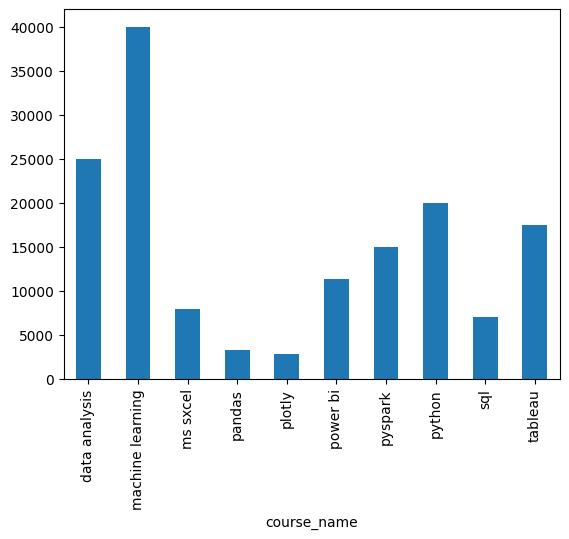

In [225]:
# 4 Plot a bar chart for revenue/courses
regestration_table.groupby('course_name')['price'].sum().plot(kind='bar')

In [226]:
# 5 Find students who enrolled in both the months
common_student_id = np.intersect1d(nov['student_id'],dec['student_id'])
student_data[student_data['student_id'].isin(common_student_id)]

,student_id,name,partner
0,1,Kailash Harjo,23
2,3,Parveen Bhalla,3
6,7,Tarun Thaker,9
10,11,David Mukhopadhyay,20
15,16,Elias Dodiya,25
16,17,Yasmin Palan,7
17,18,Fardeen Mahabir,13
21,22,Yash Sethi,21
22,23,Chhavi Lachman,18


In [227]:
#6 Find Course that got no enrollment
enrolled_courses =  reg['course_id'].unique()
courses[~courses['course_id'].isin(enrolled_courses)]

,course_id,course_name,price
10,11,Numpy,699
11,12,C++,1299


In [228]:
# or
courses.merge(reg,how='left_anti',on='course_id')['course_name']

53    Numpy
54      C++
Name: course_name, dtype: str

In [229]:
# 7 Find the students who did not enroll into any courses
student_data.merge(reg,on='student_id',how='left_anti')['name']

7            Marlo Dugal
8            Kusum Bahri
9     Lakshmi Contractor
15        Radheshyam Dey
16     Nitika Chatterjee
17        Aayushman Sant
43         Hanuman Hegde
Name: name, dtype: str

In [230]:
# print student name ---> partner name for all enrolled students
# self Join
student_data.merge(student_data,how='inner',left_on='partner',right_on='student_id')[['name_x','name_y']]

,name_x,name_y
0,Kailash Harjo,Chhavi Lachman
1,Esha Butala,Kailash Harjo
2,Parveen Bhalla,Parveen Bhalla
3,Marlo Dugal,Pranab Natarajan
4,Kusum Bahri,Lakshmi Contractor
5,Lakshmi Contractor,Aayushman Sant
6,Tarun Thaker,Nitika Chatterjee
7,Radheshyam Dey,Kusum Bahri
8,Nitika Chatterjee,Marlo Dugal
9,Aayushman Sant,Radheshyam Dey


In [231]:
# 9 Find top 3 students who did mostnumber of enrollments 
student_data.merge(reg,how='inner',on='student_id').groupby('name')['course_id'].count().sort_values(ascending=False).head(3)

name
Chhavi Lachman    6
Tarun Thaker      5
Radha Dutt        4
Name: course_id, dtype: int64

In [232]:
# 10 Find top 3 students who spent most amount of money on courses.
data= student_data.merge(reg,how='inner',on='student_id').merge(courses,on='course_id',how='inner')
data.groupby('name')['price'].sum().sort_values(ascending=False).head(3)

name
Chhavi Lachman      22594
Pranab Natarajan    15096
Qabeel Raman        13498
Name: price, dtype: int64

In [233]:
# Ipl Problems

In [234]:
#1 Find top 3 studium with highest sixes/match ratio
ipl_data1 = pd.read_csv(r"C:\Users\LENOVO\Downloads\matches.csv")
ipl_data2 = pd.read_csv(r"C:\Users\LENOVO\Downloads\deliveries.csv")

In [235]:
n1 =ipl_data1.merge(ipl_data2,left_on='id',right_on='match_id',how='left')

In [236]:
#1 Find top 3 studium with highest sixes/match ratio
six= n1[n1['batsman_runs']==6]

In [237]:
num_six = six.groupby('venue')['venue'].count()

In [251]:
six_per_match = n1['venue'].value_counts()

In [256]:
#  ratio
(six_per_match/num_six).sort_values(ascending=False).head(10) # solve again

venue
OUTsurance Oval                                         62.500000
Sheikh Zayed Stadium                                    40.600000
Shaheed Veer Narayan Singh International Stadium        32.522727
Sawai Mansingh Stadium                                  32.362140
New Wanderers Stadium                                   30.312500
Nehru Stadium                                           29.615385
Punjab Cricket Association IS Bindra Stadium, Mohali    29.586207
Dubai International Cricket Stadium                     29.310345
Subrata Roy Sahara Stadium                              28.822695
Vidarbha Cricket Association Stadium, Jamtha            28.538462
dtype: float64

In [264]:
# Find orange cap holder of all the seasons
n1.groupby(['season','batsman'])['batsman_runs'].sum().reset_index().sort_values('batsman_runs',ascending=False).drop_duplicates(['season'],keep='first').sort_values('season')

,season,batsman,batsman_runs
115,2008,SE Marsh,616
229,2009,ML Hayden,572
446,2010,SR Tendulkar,618
502,2011,CH Gayle,608
684,2012,CH Gayle,733
910,2013,MEK Hussey,733
1088,2014,RV Uthappa,660
1148,2015,DA Warner,562
1383,2016,V Kohli,973
1422,2017,DA Warner,641
